# UC-06 · Evaluate a speed change (affinity laws)

**Use case:** [UC-06 — Evaluate speed change (VFD)](../docs/product/use-cases.md)
of the registry — *given a measured `PerformanceCurve` and a target speed N₂,
produce the curve at N₂ with H, P, η transformed by the affinity laws.*

This is a worked example for the **`pump` library only** — it does **not** import
`pumpflow` (the GUI layer).  Its canvas twin is
[`example_1.pumpflow`](example_1.pumpflow), which wires the same flow as nodes:

```
Test Points (P-1001A) ─┬─▶ Speed Correction → 2000 rpm ─▶ Curve Fit ─┐
                       └─▶ Speed Correction → 1750 rpm ─▶ Curve Fit ─┴─▶ Explorer
```

We take measured Factory-Acceptance-Test points for pump **P-1001A**, correct
them to **2000 rpm** and **1750 rpm** with `PerformanceCurve.to_speed`
(Q ∝ N, H ∝ N², P ∝ N³), fit a degree-3 polynomial, and plot both speeds.

## 1 · Setup and small inline helpers

The `pump` library works in **head** and **efficiency**, but the FAT sheet gives
**suction / discharge pressures** and **breaking power**.  The library does not
(yet) ship a water-property helper, so we compute Head and η here with three tiny
functions and then **pin** them onto each `TestPoint` via the `_head=` /
`_efficiency=` cache kwargs.  Pinning matters: `to_speed` carries `_head` /
`_efficiency` through to the corrected points (scaling `breaking_power` by the
speed ratio cubed) instead of re-deriving them from pressures that the corrected
points no longer carry.

*(These helpers are deliberately self-contained — promoting water properties into
the library is a roadmap item.)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pump import Q_, Fluid, TestPoint, PerformanceCurve

G = 9.81  # m/s^2

# Density of liquid water vs temperature (Kell-style 4th-order fit, ~0-100 C).
_WATER_RHO = (999.85308, 6.32693e-2, -8.523829e-3, 6.943248e-5, -3.821216e-7)

def water_density_kgm3(temp_c: float) -> float:
    """Density of water [kg/m^3] at temp_c [deg C]."""
    return sum(c * temp_c ** i for i, c in enumerate(_WATER_RHO))

def head_m(p_suction_bar: float, p_discharge_bar: float, temp_c: float) -> float:
    """Differential head [m] = (p_dis - p_suc) / (rho * g), pressures in bar."""
    dp_pa = (p_discharge_bar - p_suction_bar) * 1.0e5
    return dp_pa / (water_density_kgm3(temp_c) * G)

def efficiency_pct(q_m3h: float, head: float, power_kw: float, temp_c: float) -> float:
    """Pump efficiency [%] = hydraulic power / breaking power."""
    rho = water_density_kgm3(temp_c)
    hydraulic_w = rho * (q_m3h / 3600.0) * G * head
    return hydraulic_w / (power_kw * 1000.0) * 100.0

## 2 · Measured test points — P-1001A

Six rows from the performance test: capacity Q, suction/discharge pressure (bar),
water temperature, shaft speed and breaking power.  All points share **one**
`Fluid` (the library requires it); since Head/η are pinned per row, the fluid's
density is effectively just a label, so we set it to water at the mean test
temperature.

In [2]:
#         Q[m3/h] p_suc  p_dis   T[C]   N[rpm]  P[kW]
rows = [
    (160.0, 1.48, 13.77, 19.5, 1481.0,  78.0),
    (240.0, 1.50, 13.16, 20.0, 1480.0,  95.0),
    (320.0, 1.50, 12.33, 20.2, 1479.0, 114.0),
    (400.0, 1.51, 11.30, 20.0, 1480.0, 147.0),
    (480.0, 1.50, 10.00, 20.5, 1481.0, 174.0),
    (540.0, 1.49,  8.88, 20.3, 1479.0, 194.0),
]

mean_temp = sum(r[3] for r in rows) / len(rows)
water = Fluid(name="Test water", density=Q_(water_density_kgm3(mean_temp), "kg/m**3"))

points = []
print(f"{'Q':>7} {'Head':>8} {'eta%':>7}   (measured, pinned onto each TestPoint)")
for q, p_suc, p_dis, t, n, power in rows:
    h = head_m(p_suc, p_dis, t)
    e = efficiency_pct(q, h, power, t)
    points.append(TestPoint(
        fluid=water,
        capacity=Q_(q, "m**3/h"),
        speed_of_rotation=Q_(n, "rpm"),
        _head=Q_(h, "m"),
        _efficiency=Q_(e, "percent"),
        breaking_power=Q_(power, "kW"),
    ))
    print(f"{q:7.0f} {h:8.2f} {e:7.1f}")

      Q     Head    eta%   (measured, pinned onto each TestPoint)
    160   125.49    70.0
    240   119.07    81.8
    320   110.60    84.4
    400    99.98    74.0
    480    86.81    65.1
    540    75.47    57.1


## 3 · Build the curve and correct the speed

`PerformanceCurve.to_speed` applies the affinity laws and **returns a new curve**
(it never mutates in place).  We correct the same measured curve to 2000 rpm and
to 1750 rpm.

In [3]:
curve = PerformanceCurve(water, points, polynomial_degree=3)

branches = {}
for speed in (2000.0, 1750.0):
    corrected = curve.to_speed(Q_(speed, "rpm"))
    branches[speed] = corrected
    print(f"\n=== corrected to {speed:g} rpm ===")
    print(f"{'Q_corr':>8} {'H_corr':>8} {'P_corr':>9} {'eta%':>7}")
    for p in corrected.points:
        q = p.capacity.to("m**3/h").magnitude
        h = p.head.to("m").magnitude
        pw = p.breaking_power.to("kW").magnitude
        e = p.efficiency.to("percent").magnitude
        print(f"{q:8.1f} {h:8.2f} {pw:9.2f} {e:7.1f}")


=== corrected to 2000 rpm ===
  Q_corr   H_corr    P_corr    eta%
   216.1   228.86    192.10    70.0
   324.3   217.44    234.44    81.8
   432.7   202.25    281.90    84.4
   540.5   182.57    362.76    74.0
   648.2   158.32    428.52    65.1
   730.2   138.01    479.72    57.1

=== corrected to 1750 rpm ===
  Q_corr   H_corr    P_corr    eta%
   189.1   175.22    128.69    70.0
   283.8   166.48    157.06    81.8
   378.6   154.85    188.85    84.4
   473.0   139.78    243.02    74.0
   567.2   121.21    287.08    65.1
   638.9   105.66    321.37    57.1


**UC-06 acceptance** (registry): a round-trip `curve.to_speed(N).to_speed(N0)`
must return to the original within `< 1e-6` at corresponding Q.  We check it on a
single-speed curve — the 2000 rpm corrected curve — since the *raw* test points
were logged at slightly varying speeds (1479–1481 rpm), for which a single-N₀
round-trip is not expected to be exact.

In [4]:
base = branches[2000.0]
back = base.to_speed(Q_(1750.0, "rpm")).to_speed(Q_(2000.0, "rpm"))
max_dh = max(
    abs(a.head.to("m").magnitude - b.head.to("m").magnitude)
    for a, b in zip(base.points, back.points)
)
print(f"max |dHead| after 2000 -> 1750 -> 2000 round-trip = {max_dh:.2e} m")

max |dHead| after 2000 -> 1750 -> 2000 round-trip = 2.84e-14 m


## 4 · Degree-3 polynomial fit

The fitter exposes the least-squares coefficients (the API 610 primary fit) for
Head, Power and Efficiency vs capacity.

In [5]:
for speed, c in branches.items():
    f = c.fitter
    print(f"{speed:g} rpm")
    print("   head  coeffs:", np.round(f.head_coeffs, 6))
    print("   power coeffs:", np.round(f.power_coeffs, 6))
    print("   eff   coeffs:", np.round(f.efficiency_coeffs, 6))

2000 rpm
   head  coeffs: [ 0.00000000e+00 -2.09000000e-04  5.53200000e-03  2.37125155e+02]
   power coeffs: [-1.00000000e-06  2.15600000e-03 -5.40398000e-01  2.22165419e+02]
   eff   coeffs: [ 1.0000000e-06 -1.1530000e-03  6.0233100e-01 -1.2855043e+01]
1750 rpm
   head  coeffs: [ 0.00000000e+00 -2.09000000e-04  4.84100000e-03  1.81548947e+02]
   power coeffs: [-1.00000000e-06  1.88700000e-03 -4.13742000e-01  1.48833474e+02]
   eff   coeffs: [ 1.0000000e-06 -1.5050000e-03  6.8837800e-01 -1.2855043e+01]


## 5 · Overlay plot — both speeds

Three stacked, capacity-linked panes (Q×H / Q×P / Q×η): each branch's fitted
polynomial as a line, with the corrected points as triangle markers.

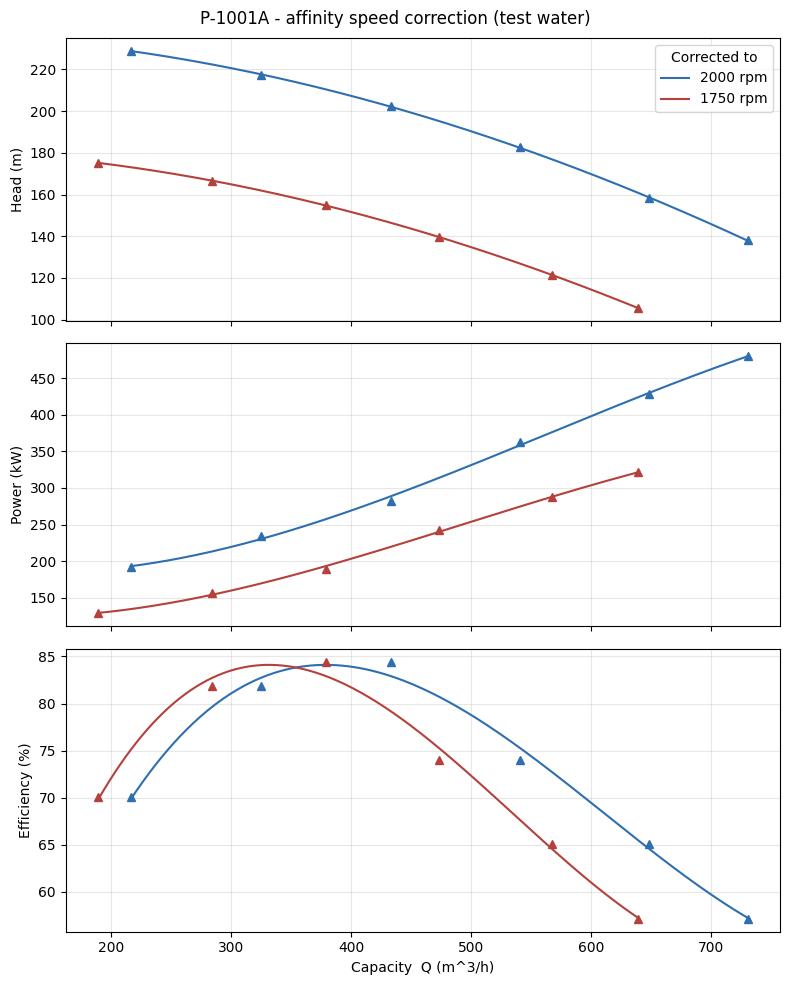

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
ax_h, ax_p, ax_e = axes
colors = {2000.0: "#2f6fb0", 1750.0: "#b4413c"}

for speed, c in branches.items():
    color = colors[speed]
    f = c.fitter
    caps = np.asarray(f.capacities, dtype=float)
    xs = np.linspace(caps.min(), caps.max(), 200)
    ax_h.plot(xs, np.polyval(f.head_coeffs, xs), color=color, label=f"{speed:g} rpm")
    ax_p.plot(xs, np.polyval(f.power_coeffs, xs), color=color)
    ax_e.plot(xs, np.polyval(f.efficiency_coeffs, xs), color=color)
    ax_h.plot(caps, f.heads, "^", color=color)
    ax_p.plot(caps, f.powers, "^", color=color)
    ax_e.plot(caps, f.efficiencies, "^", color=color)

ax_h.set_ylabel("Head (m)")
ax_p.set_ylabel("Power (kW)")
ax_e.set_ylabel("Efficiency (%)")
ax_e.set_xlabel("Capacity  Q (m^3/h)")
ax_h.legend(title="Corrected to")
for ax in axes:
    ax.grid(alpha=0.3)
fig.suptitle("P-1001A - affinity speed correction (test water)")
fig.tight_layout()
plt.show()

## 6 · Read predicted values at a chosen flow

The library predictors evaluate the fitted curve at any capacity — the analogue
of the workbench's flow readout.

In [7]:
q_read = Q_(400.0, "m**3/h")
print(f"Predicted values at Q = {q_read.magnitude:g} m^3/h")
print(f"{'branch':>10} {'Head [m]':>10} {'Power [kW]':>12} {'eta [%]':>9}")
for speed, c in branches.items():
    h = c.predict_head(q_read).to("m").magnitude
    p = c.predict_breaking_power(q_read).to("kW").magnitude
    e = c.predict_efficiency(q_read).to("percent").magnitude
    print(f"{speed:>7g}rpm {h:10.2f} {p:12.2f} {e:9.1f}")

Predicted values at Q = 400 m^3/h
    branch   Head [m]   Power [kW]   eta [%]
   2000rpm     207.26       269.20      83.9
   1750rpm     151.60       203.41      81.7
